Kernel PCA in Python

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA


In [4]:
X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)
print(X.shape)
print(y.shape)

(400, 2)
(400,)


Andiamo a rappresentare la distribuzione dei dati

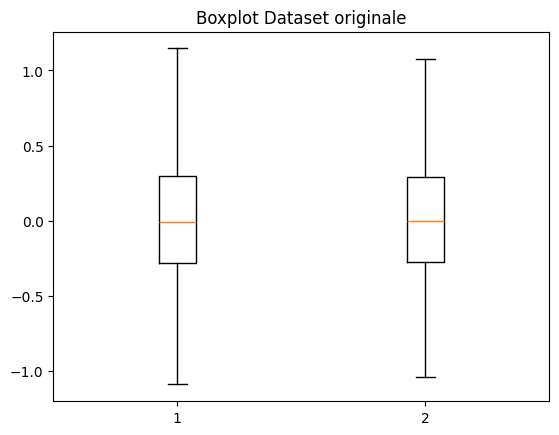

In [6]:
plt.boxplot(X)
plt.title("Boxplot Dataset originale")
plt.show()


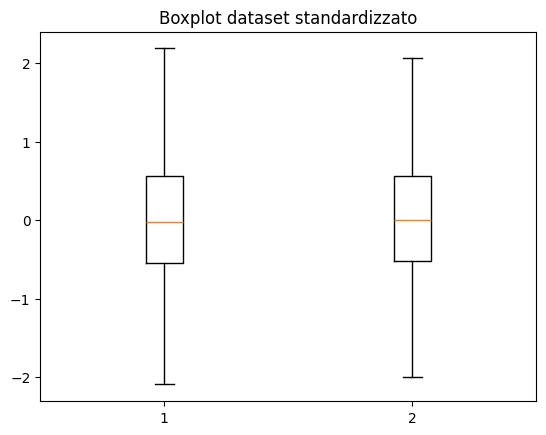

In [7]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

plt.boxplot(X_std)
plt.title("Boxplot dataset standardizzato")
plt.show()

Creazione Kernel PCA

In [8]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=15)
X_kpca = kpca.fit_transform(X_std)

print(X_kpca.shape)


(400, 2)


In [9]:
n_clusters = 2
random_state = 42


In [21]:
kmeans_std = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
clusters_std = kmeans_std.fit_predict(X_kpca)
centroids_std = kmeans_std.cluster_centers_


In [22]:
kmeans_kpca = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
clusters_kpca = kmeans_kpca.fit_predict(X_std)
centroids_kpca = kmeans_kpca.cluster_centers_

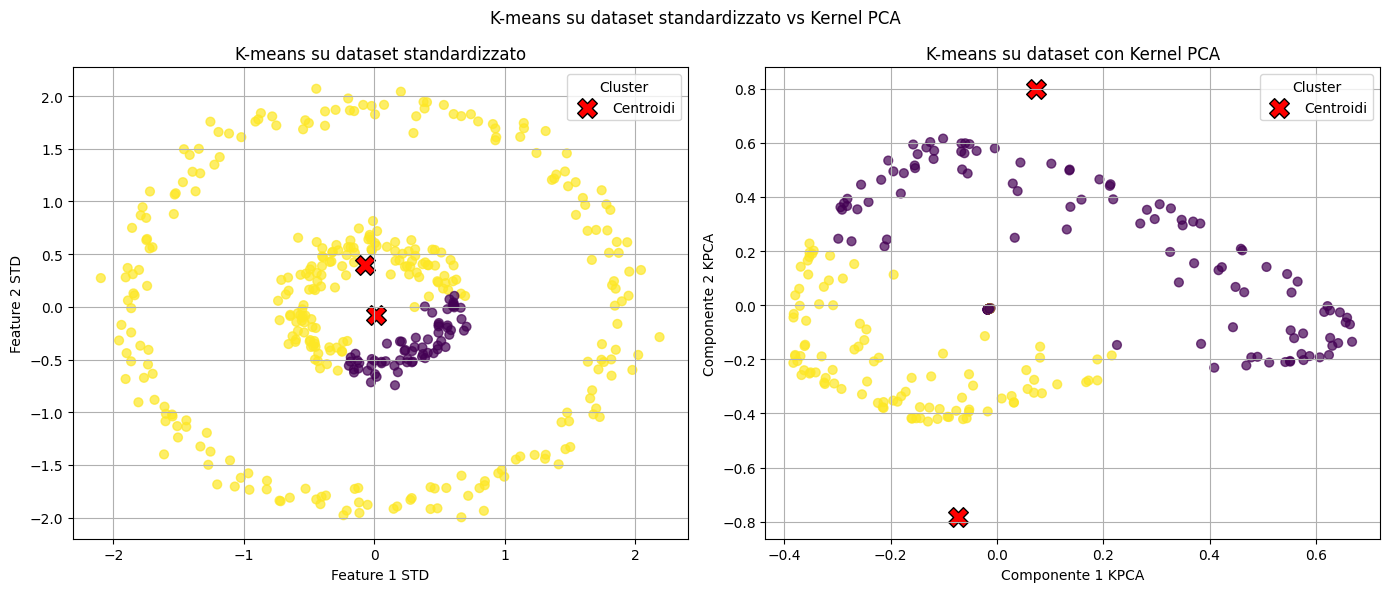

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("K-means su dataset standardizzato vs Kernel PCA")

axes[0].scatter(X_std[:, 0], X_std[:, 1], c=clusters_std, cmap='viridis', s=40, alpha=0.7)
axes[0].scatter(centroids_std[:, 0], centroids_std[:, 1], c='red', marker='X', s=200, edgecolor='black', label='Centroidi')
axes[0].set_title("K-means su dataset standardizzato")
axes[0].set_xlabel("Feature 1 STD")
axes[0].set_ylabel("Feature 2 STD")
axes[0].grid()
axes[0].legend(title="Cluster")

axes[1].scatter(X_kpca[:, 0], X_kpca[:, 1], c=clusters_kpca, cmap='viridis', s=40, alpha=0.7)
axes[1].scatter(centroids_kpca[:, 0], centroids_kpca[:, 1], c='red', marker='X', s=200, edgecolor='black', label='Centroidi')
axes[1].set_title("K-means su dataset con Kernel PCA")
axes[1].set_xlabel("Componente 1 KPCA")
axes[1].set_ylabel("Componente 2 KPCA")
axes[1].grid()
axes[1].legend(title="Cluster")

plt.tight_layout()
plt.show()

In [24]:
import time

n_clusters = 3
random_state = 42

kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
start_std = time.time()
kmeans.fit(X_std)
end_std = time.time()
time_std = round((end_std - start_std) *1000, 3)

kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_state, n_init="auto")
start_pca = time.time()
kmeans_pca.fit(X_pca)
end_pca = time.time()
time_pca = round((end_pca - start_pca) *1000, 3)

print(f"KMeans su X_std: {time_std} millisecondi")
print(f"KMeans su X_pca: {time_pca} millisecondi")

KMeans su X_std: 4.276 millisecondi
KMeans su X_pca: 3.104 millisecondi
